In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import random

2025-03-05 20:58:24.860031: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-05 20:58:27.412118: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-05 20:58:27.428524: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-05 20:58:31.980253: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [22]:
data = pd.read_csv("/home/apiiit123/Downloads/11/data.csv")
data

,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,...,Smoking_Status,Alcohol_Consumption,Health_Score,PCOS (Y/N),Blood Group,Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,PCOS (Y/N).1,Hb(g/dl)
0,P0001,56,Male,58.4,160,22.8,Obesity,Moderate,Moderate,3079,...,0,2.834707,70.542122,0.0,15.0,7.0,0.0,0.0,0.0,10.48
1,P0002,69,Male,101.2,169,35.4,Diabetes,Mild,Moderate,3032,...,1,7.199517,57.244637,0.0,15.0,11.0,1.0,0.0,0.0,11.70
2,P0003,46,Female,63.5,173,21.2,Hypertension,Mild,Sedentary,1737,...,1,4.097944,96.333722,1.0,11.0,10.0,1.0,0.0,1.0,11.80
3,P0004,32,Male,58.1,164,21.6,NaN,Mild,Moderate,2657,...,1,3.649377,61.321783,0.0,13.0,4.0,0.0,0.0,0.0,12.00
4,P0005,60,Male,79.5,197,20.5,Diabetes,Moderate,Sedentary,3496,...,0,2.839795,67.175894,0.0,11.0,1.0,1.0,0.0,0.0,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,P0996,18,Male,72.1,160,28.2,Obesity,Moderate,Active,2639,...,0,3.823116,67.993747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,P0997,35,Female,104.0,171,35.6,Hypertension,Moderate,Moderate,1661,...,1,5.597395,72.377621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,P0998,49,Female,56.0,182,16.9,Obesity,Severe,Moderate,3102,...,0,8.195167,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
998,P0999,64,Male,66.6,185,19.5,Diabetes,Severe,Active,3235,...,0,3.676134,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
data.head()

,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,...,Smoking_Status,Alcohol_Consumption,Health_Score,PCOS (Y/N),Blood Group,Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,PCOS (Y/N).1,Hb(g/dl)
0,P0001,56,Male,58.4,160,22.8,Obesity,Moderate,Moderate,3079,...,0,2.834707,70.542122,0.0,15.0,7.0,0.0,0.0,0.0,10.48
1,P0002,69,Male,101.2,169,35.4,Diabetes,Mild,Moderate,3032,...,1,7.199517,57.244637,0.0,15.0,11.0,1.0,0.0,0.0,11.70
2,P0003,46,Female,63.5,173,21.2,Hypertension,Mild,Sedentary,1737,...,1,4.097944,96.333722,1.0,11.0,10.0,1.0,0.0,1.0,11.80
3,P0004,32,Male,58.1,164,21.6,NaN,Mild,Moderate,2657,...,1,3.649377,61.321783,0.0,13.0,4.0,0.0,0.0,0.0,12.00
4,P0005,60,Male,79.5,197,20.5,Diabetes,Moderate,Sedentary,3496,...,0,2.839795,67.175894,0.0,11.0,1.0,1.0,0.0,0.0,10.00


In [24]:
data.shape

(1000, 33)

In [25]:
data.tail()

,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,...,Smoking_Status,Alcohol_Consumption,Health_Score,PCOS (Y/N),Blood Group,Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,PCOS (Y/N).1,Hb(g/dl)
995,P0996,18,Male,72.1,160,28.2,Obesity,Moderate,Active,2639,...,0,3.823116,67.993747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,P0997,35,Female,104.0,171,35.6,Hypertension,Moderate,Moderate,1661,...,1,5.597395,72.377621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,P0998,49,Female,56.0,182,16.9,Obesity,Severe,Moderate,3102,...,0,8.195167,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
998,P0999,64,Male,66.6,185,19.5,Diabetes,Severe,Active,3235,...,0,3.676134,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999,P1000,66,Female,101.3,194,26.9,Obesity,Severe,Moderate,2042,...,0,4.291944,87.995811,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        1000 non-null   object 
 1   Age                               1000 non-null   int64  
 2   Gender                            1000 non-null   object 
 3   Weight_kg                         1000 non-null   float64
 4   Height_cm                         1000 non-null   int64  
 5   BMI                               1000 non-null   float64
 6   Disease_Type                      796 non-null    object 
 7   Severity                          1000 non-null   object 
 8   Physical_Activity_Level           1000 non-null   object 
 9   Daily_Caloric_Intake              1000 non-null   int64  
 10  Cholesterol_mg/dL                 1000 non-null   float64
 11  Blood_Pressure_mmHg               1000 non-null   int64  
 12  Glucose

In [27]:
data.describe()

,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,...,Smoking_Status,Alcohol_Consumption,Health_Score,PCOS (Y/N),Blood Group,Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,PCOS (Y/N).1,Hb(g/dl)
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.000000,541.000000,541.000000,540.000000,541.000000,541.000000,541.000000,541.000000
mean,49.857000,84.602400,174.81700,28.191600,2475.064000,199.717900,144.993000,136.867600,5.166000,74.88430,...,0.499000,3.079377,85.479947,0.327172,13.802218,7.680926,0.380776,0.288355,0.327172,11.160037
std,18.114267,20.088121,14.33377,8.040136,565.017032,29.080614,20.245712,37.934819,2.847995,14.82638,...,0.500249,2.084564,13.633845,0.469615,1.840812,4.803835,0.486027,0.692575,0.469615,0.866904
min,18.000000,50.000000,150.00000,13.000000,1500.000000,150.400000,110.000000,70.200000,0.000000,50.00000,...,0.000000,-3.592506,29.106017,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,8.500000
25%,35.000000,66.600000,162.00000,22.075000,1984.750000,174.300000,128.000000,105.000000,2.800000,62.00000,...,0.000000,1.644111,76.430819,0.000000,13.000000,4.000000,0.000000,0.000000,0.000000,10.500000
50%,50.000000,85.200000,175.00000,27.450000,2470.500000,199.850000,145.000000,138.000000,5.200000,74.20000,...,0.000000,3.064261,87.498996,0.000000,14.000000,7.000000,0.000000,0.000000,0.000000,11.000000
75%,66.000000,102.000000,187.00000,33.425000,2937.250000,224.850000,163.000000,170.650000,7.600000,88.20000,...,1.000000,4.489293,99.762644,1.000000,15.000000,10.000000,1.000000,0.000000,1.000000,11.700000
max,79.000000,119.700000,199.00000,52.400000,3498.000000,249.900000,179.000000,200.000000,10.000000,100.00000,...,1.000000,11.105100,100.000000,1.000000,18.000000,30.000000,1.000000,5.000000,1.000000,14.800000


In [28]:
data.ndim

2

In [29]:
data.isnull().sum()

Patient_ID                            0
Age                                   0
Gender                                0
Weight_kg                             0
Height_cm                             0
BMI                                   0
Disease_Type                        204
Severity                              0
Physical_Activity_Level               0
Daily_Caloric_Intake                  0
Cholesterol_mg/dL                     0
Blood_Pressure_mmHg                   0
Glucose_mg/dL                         0
Dietary_Restrictions                334
Allergies                           323
Preferred_Cuisine                     0
Weekly_Exercise_Hours                 0
Adherence_to_Diet_Plan                0
Dietary_Nutrient_Imbalance_Score      0
Diet_Recommendation                   0
Exercise_Frequency                    0
Diet_Quality                          0
Sleep_Hours                           0
Smoking_Status                        0
Alcohol_Consumption                   0


In [30]:
data.nunique

<bound method DataFrame.nunique of     Patient_ID  Age  Gender  Weight_kg  Height_cm   BMI  Disease_Type  \
0        P0001   56    Male       58.4        160  22.8       Obesity   
1        P0002   69    Male      101.2        169  35.4      Diabetes   
2        P0003   46  Female       63.5        173  21.2  Hypertension   
3        P0004   32    Male       58.1        164  21.6           NaN   
4        P0005   60    Male       79.5        197  20.5      Diabetes   
..         ...  ...     ...        ...        ...   ...           ...   
995      P0996   18    Male       72.1        160  28.2       Obesity   
996      P0997   35  Female      104.0        171  35.6  Hypertension   
997      P0998   49  Female       56.0        182  16.9       Obesity   
998      P0999   64    Male       66.6        185  19.5      Diabetes   
999      P1000   66  Female      101.3        194  26.9       Obesity   

     Severity Physical_Activity_Level  Daily_Caloric_Intake  ...  \
0    Moderate       

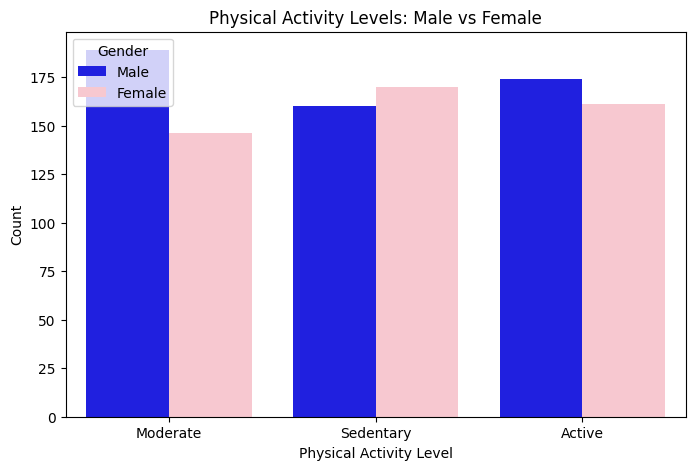

In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="Physical_Activity_Level", hue="Gender", palette={"Male": "blue", "Female": "pink"})
plt.title("Physical Activity Levels: Male vs Female")
plt.xlabel("Physical Activity Level")
plt.ylabel("Count")
plt.legend(title="Gender", labels=["Male", "Female"])
plt.show()

Text(0.5, 0.98, 'Histograms for Dietary Score, PCOS, and Hemoglobin Levels in Women')

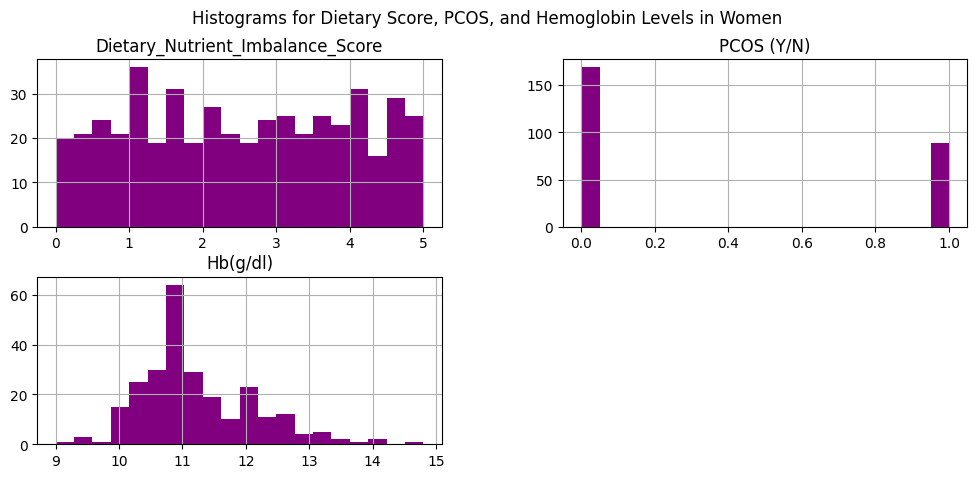

In [32]:
women_df = data[data["Gender"] == "Female"]
women_df[["Dietary_Nutrient_Imbalance_Score", "PCOS (Y/N)", "Hb(g/dl)"]].hist(bins=20, figsize=(12, 5), color=["purple"])
plt.suptitle("Histograms for Dietary Score, PCOS, and Hemoglobin Levels in Women")

array([<Axes: title={'center': 'Women'}, ylabel='Female'>,
       <Axes: title={'center': 'Men'}, ylabel='Male'>], dtype=object)

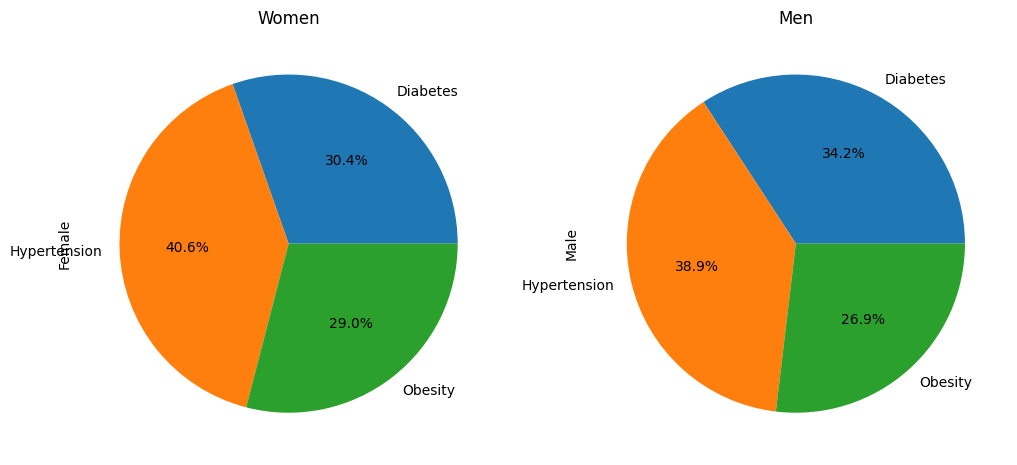

In [33]:
disease_counts = data.groupby("Gender")["Disease_Type"].value_counts().unstack()
disease_counts.T.plot(kind="pie", subplots=True, figsize=(12, 6), autopct="%1.1f%%", legend=False, title=["Women", "Men"])

In [34]:
features = ["BMI", "Health_Score", "Hb(g/dl)", "Daily_Caloric_Intake", "Dietary_Nutrient_Imbalance_Score"]
x = women_df[features].dropna()

In [35]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [36]:
y = women_df[features]
y

,BMI,Health_Score,Hb(g/dl),Daily_Caloric_Intake,Dietary_Nutrient_Imbalance_Score
2,21.2,96.333722,11.8,1737,4.6
5,43.4,100.000000,11.2,2715,3.5
11,27.6,94.247684,9.5,1622,1.9
17,26.4,98.865075,10.8,1979,3.8
19,30.1,81.539122,12.5,2542,1.5
...,...,...,...,...,...
990,48.1,83.116872,NaN,2338,0.2
994,21.2,80.900641,NaN,3397,3.3
996,35.6,72.377621,NaN,1661,2.9
997,16.9,100.000000,NaN,3102,4.8


In [37]:
gmm = GaussianMixture(n_components=3, random_state=42)
women_df.loc[x.index, "Disease_Cluster_GMM"] = gmm.fit_predict(x_scaled)  # Assign clusters only to non-null rows
print(women_df[["Disease_Type", "Disease_Cluster_GMM"]].drop_duplicates())

     Disease_Type  Disease_Cluster_GMM
2    Hypertension                  0.0
5         Obesity                  1.0
11       Diabetes                  0.0
20            NaN                  1.0
25        Obesity                  0.0
32   Hypertension                  2.0
37       Diabetes                  2.0
48       Diabetes                  1.0
50   Hypertension                  1.0
55        Obesity                  2.0
57            NaN                  2.0
80            NaN                  0.0
541           NaN                  NaN
542  Hypertension                  NaN
545      Diabetes                  NaN
553       Obesity                  NaN


/tmp/ipykernel_60622/1217194073.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  women_df.loc[x.index, "Disease_Cluster_GMM"] = gmm.fit_predict(x_scaled)  # Assign clusters only to non-null rows


In [38]:
valid_indices = women_df[features].dropna().index 
labels = women_df.loc[valid_indices, "Disease_Type"].values 

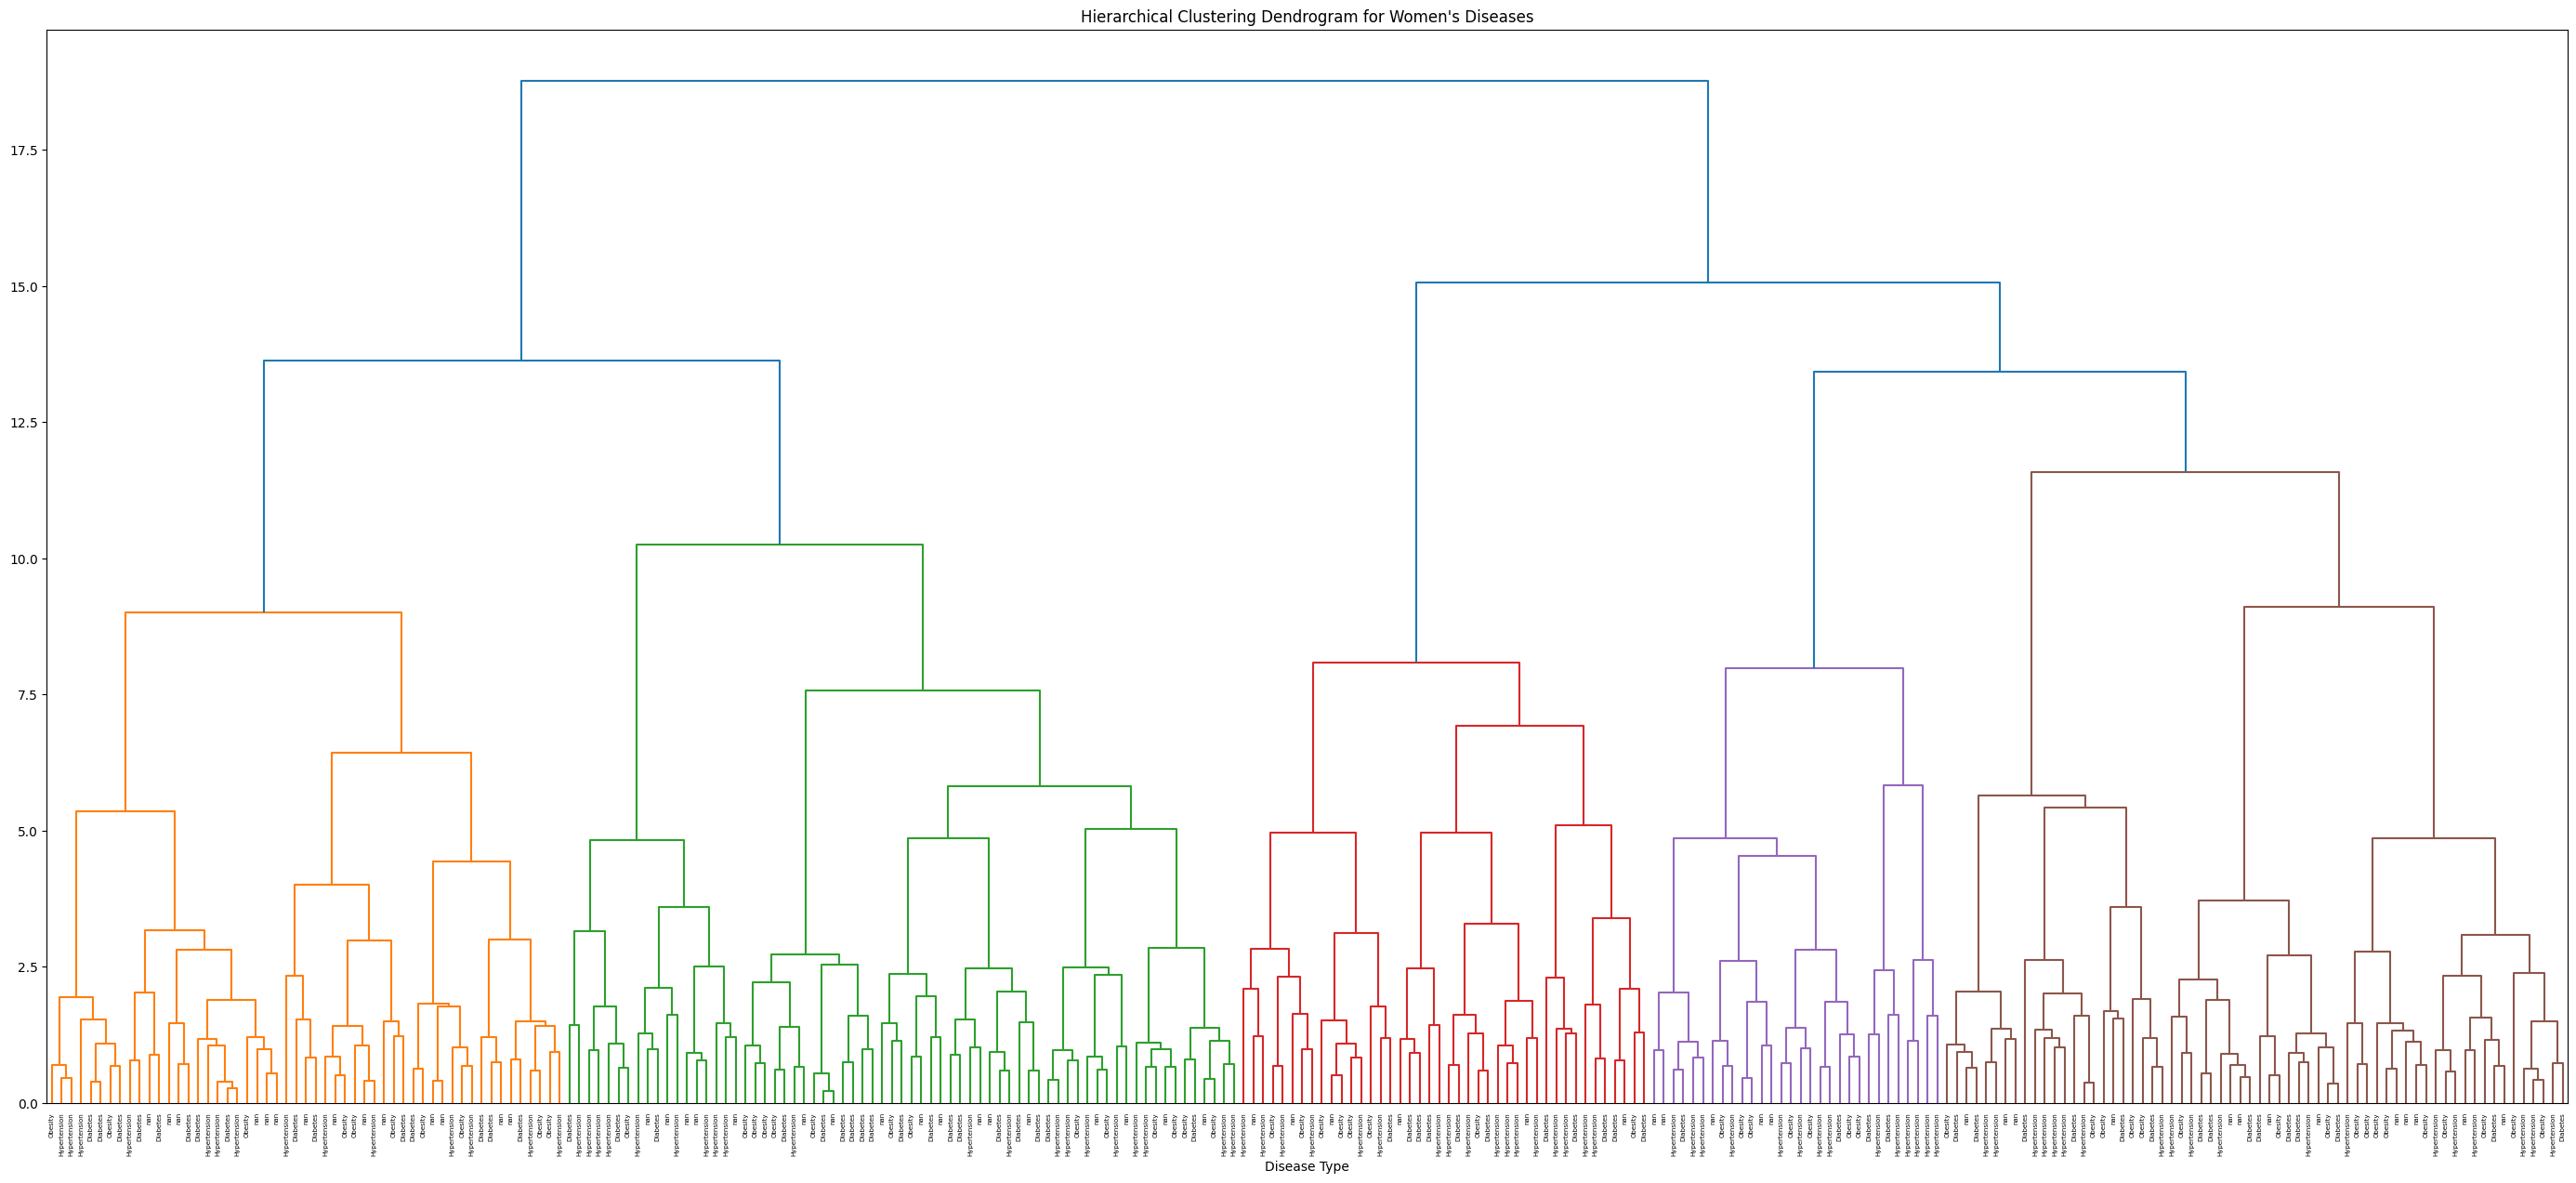

In [39]:
linked = linkage(x_scaled, method='ward')
plt.figure(figsize=(35, 15))
dendrogram(linked, labels=labels, orientation="top", leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram for Women's Diseases")
plt.xlabel("Disease Type")
plt.show()

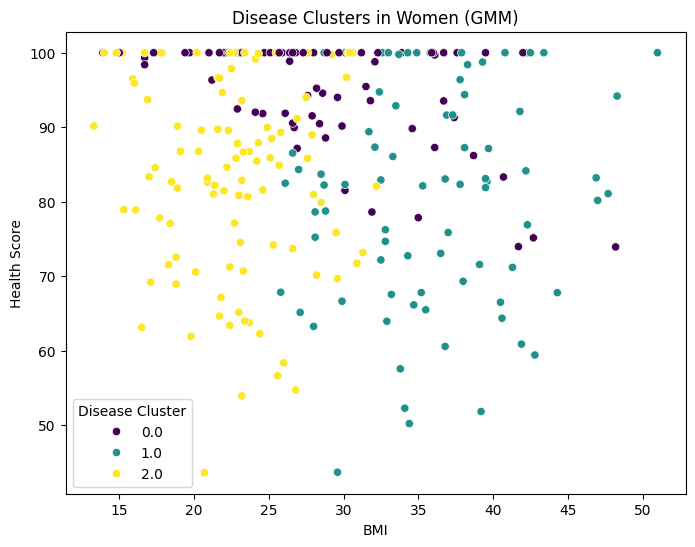

In [40]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=x["BMI"], y=x["Health_Score"], hue=women_df["Disease_Cluster_GMM"], palette="viridis")
plt.title("Disease Clusters in Women (GMM)")
plt.xlabel("BMI")
plt.ylabel("Health Score")
plt.legend(title="Disease Cluster")
plt.show()

/tmp/ipykernel_60622/2652150894.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.index, y=disease_counts.values, palette="coolwarm")


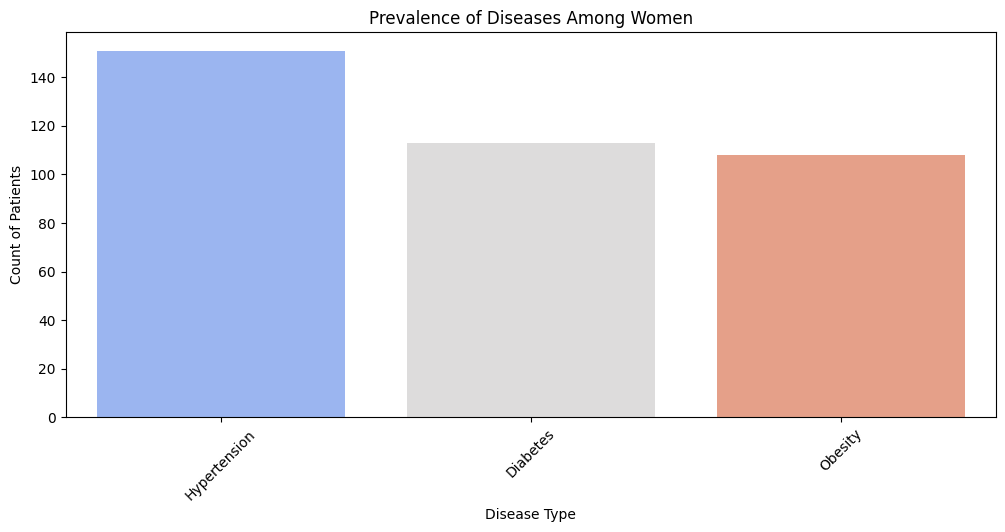

In [41]:
#the common diseases among women
disease_counts = women_df["Disease_Type"].value_counts()
plt.figure(figsize=(12, 5))
sns.barplot(x=disease_counts.index, y=disease_counts.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.xlabel("Disease Type")
plt.ylabel("Count of Patients")
plt.title("Prevalence of Diseases Among Women")
plt.show()

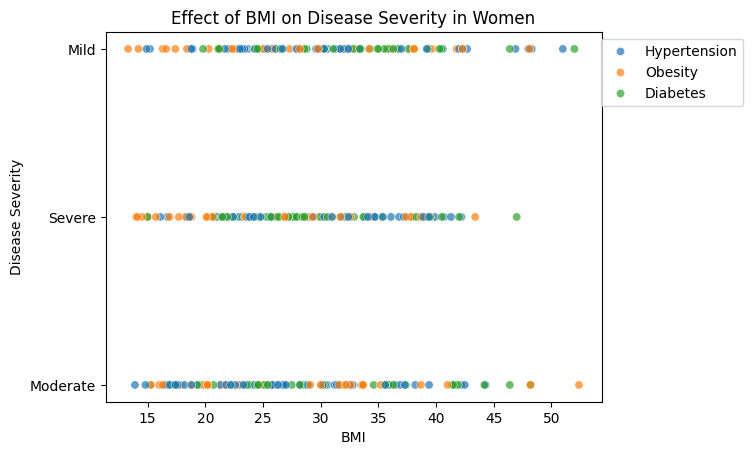

In [42]:
sns.scatterplot(data=women_df, x="BMI", y="Severity", hue="Disease_Type", alpha=0.7, palette="tab10")
plt.xlabel("BMI")
plt.ylabel("Disease Severity")
plt.title("Effect of BMI on Disease Severity in Women")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.show()

In [45]:
df = women_df.dropna(subset=["Disease_Type", "Disease_Cluster_GMM"])
X = df[["BMI", "Health_Score", "Hb(g/dl)", "Daily_Caloric_Intake", "Dietary_Nutrient_Imbalance_Score"]]
y = df["Disease_Type"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [50]:
#Predicts high-risk diseases like obesity, diabetes, and hypertension based on health factors.
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5365853658536586
Classification Report:
               precision    recall  f1-score   support

    Diabetes       0.46      0.46      0.46        13
Hypertension       0.81      0.57      0.67        23
     Obesity       0.25      0.60      0.35         5

    accuracy                           0.54        41
   macro avg       0.51      0.54      0.49        41
weighted avg       0.63      0.54      0.56        41



In [54]:
#Shows which health parameters (BMI, Health Score, etc.) impact disease risk the most.
feature_importance_rf = rf.feature_importances_

In [55]:
feature_importance_df_rf = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance_rf})
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='Importance', ascending=False)

/tmp/ipykernel_60622/2551073754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance_df_rf, palette="viridis")


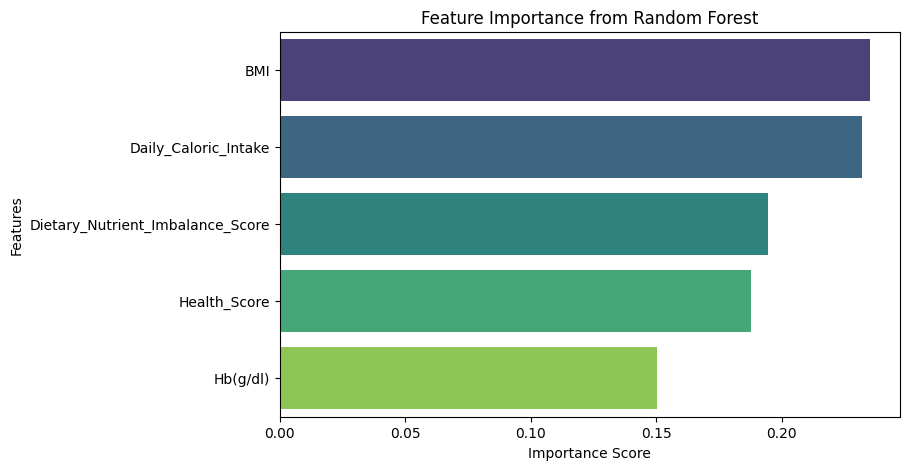

In [56]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df_rf, palette="viridis")
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [60]:
# provides personalized health recommendations based on user behavior.
class HealthEnv:
    def __init__(self):
        self.state = np.array([50, 1, 0, 0])  # [Health Score, BMI, Exercise, Diet Compliance]
        self.actions = 4  # [Exercise, Diet Change, Doctor Visit, Mental Wellness]

    def step(self, action):
        rewards = [15 if self.state[2] else -5, 10 if self.state[3] else -5, 5 if self.state[0] < 70 else -2, 5]
        self.state[0] = min(100, self.state[0] + rewards[action])
        return self.state, rewards[action]

In [63]:
#model for personalized health plans 
model = tf.keras.Sequential([
    tf.keras.layers.Dense(24, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(4, activation='linear')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="mse")

In [62]:
env = HealthEnv()
for _ in range(500):
    state = env.state
    action = random.randint(0, 3) if np.random.rand() < 0.1 else np.argmax(model.predict(np.array([state])))
    next_state, reward = env.step(action)
    target = reward + 0.9 * np.max(model.predict(np.array([next_state])))
    target_f = model.predict(np.array([state]))
    target_f[0][action] = target
    model.fit(np.array([state]), target_f, epochs=1, verbose=0)

1/1 [==============================] - 0s 23ms/step
